In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
output_dir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_export'

# 1. Load X matrix
if os.path.exists(f'{output_dir}/X_matrix.npz'):
    X = sp.load_npz(f'{output_dir}/X_matrix.npz')
    print("Loaded sparse X matrix")
else:
    X = np.load(f'{output_dir}/X_matrix.npy')
    print("Loaded dense X matrix")

# 2. Load obs and var
obs = pd.read_csv(f'{output_dir}/obs.csv', index_col=0)
var = pd.read_csv(f'{output_dir}/var.csv', index_col=0)
print(f"Loaded obs: {obs.shape}, var: {var.shape}")

# 3. Create AnnData object
adata = ad.AnnData(X=X, obs=obs, var=var)
print(f"Created AnnData: {adata.shape}")

# 4. Load obsm
for file in glob.glob(f'{output_dir}/obsm_*.csv'):
    key = file.split('obsm_')[1].replace('.csv', '')
    df = pd.read_csv(file, index_col=0)
    adata.obsm[key] = df.values
    print(f"Loaded obsm['{key}']: {df.shape}")

# 5. Load varm
for file in glob.glob(f'{output_dir}/varm_*.csv'):
    key = file.split('varm_')[1].replace('.csv', '')
    df = pd.read_csv(file, index_col=0)
    adata.varm[key] = df.values
    print(f"Loaded varm['{key}']: {df.shape}")

# 6. Load obsp
for file in glob.glob(f'{output_dir}/obsp_*.npz'):
    key = file.split('obsp_')[1].replace('.npz', '')
    adata.obsp[key] = sp.load_npz(file)
    print(f"Loaded obsp['{key}']")

# 7. Load varp
for file in glob.glob(f'{output_dir}/varp_*.npz'):
    key = file.split('varp_')[1].replace('.npz', '')
    adata.varp[key] = sp.load_npz(file)
    print(f"Loaded varp['{key}']")

# 8. Load uns
adata.uns = {}
if os.path.exists(f'{output_dir}/uns.json'):
    with open(f'{output_dir}/uns.json', 'r') as f:
        adata.uns.update(json.load(f))
    print(f"Loaded {len(adata.uns)} entries from uns.json")

# Load numpy arrays in uns
for file in glob.glob(f'{output_dir}/uns_*.npy'):
    key = os.path.basename(file).split('uns_')[1].replace('.npy', '')
    adata.uns[key] = np.load(file, allow_pickle=True)
    print(f"Loaded uns['{key}']")

# Load DataFrames in uns
for file in glob.glob(f'{output_dir}/uns_*.csv'):
    key = os.path.basename(file).split('uns_')[1].replace('.csv', '')
    adata.uns[key] = pd.read_csv(file, index_col=0)
    print(f"Loaded uns['{key}']")

# 9. Load raw if exists
if os.path.exists(f'{output_dir}/raw_X.npz'):
    raw_X = sp.load_npz(f'{output_dir}/raw_X.npz')
    print("Loaded raw sparse matrix")
elif os.path.exists(f'{output_dir}/raw_X.npy'):
    raw_X = np.load(f'{output_dir}/raw_X.npy')
    print("Loaded raw dense matrix")
else:
    raw_X = None

if raw_X is not None:
    raw_var = pd.read_csv(f'{output_dir}/raw_var.csv', index_col=0)
    adata.raw = ad.AnnData(X=raw_X, var=raw_var, obs=adata.obs)
    print(f"Loaded raw data: {adata.raw.X.shape}")

# Before step 10, add this cleaning step:

# Clean uns to remove problematic entries
print("\nChecking uns entries:")
uns_cleaned = {}
for key, val in adata.uns.items():
    try:
        # Try to create a temporary h5ad file to test if this entry can be saved
        test_adata = ad.AnnData(X=adata.X[:10, :10], obs=adata.obs.iloc[:10], var=adata.var.iloc[:10])
        test_adata.uns[key] = val
        test_adata.write('/tmp/test_uns.h5ad')
        uns_cleaned[key] = val
        print(f"  ✓ uns['{key}'] - OK")
    except Exception as e:
        print(f"  ✗ uns['{key}'] - Error: {type(e).__name__}")
        # Try to convert to something saveable
        if isinstance(val, dict):
            print(f"    Attempting to clean dict...")
            try:
                # For dict entries, try to save just the serializable parts
                clean_dict = {}
                for k, v in val.items():
                    if isinstance(v, (str, int, float, bool, np.ndarray, list)):
                        clean_dict[k] = v
                uns_cleaned[key] = clean_dict
                print(f"    Cleaned dict saved")
            except:
                print(f"    Skipping {key}")
        else:
            print(f"    Skipping {key}")

# Replace uns with cleaned version
adata.uns = uns_cleaned
print(f"\nCleaned uns: {len(uns_cleaned)} entries retained")

# 10. Now save with anndata 0.10.8
output_path = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_celloracle_compatible.h5ad'
adata.write(output_path)

print(f"\n✓ Reconstructed AnnData saved!")
print(f"  Shape: {adata.shape}")
print(f"  File: {output_path}")
print(f"  obsm keys: {list(adata.obsm.keys())}")
print(f"  uns keys: {list(adata.uns.keys())}")

### Filter cells 

In [2]:
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_celloracle_compatible.h5ad')

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
print(adata.X.min())
print(adata.X.max())

0.0
8.653730285872221


In [6]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[:, (~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb'])] # Filter mitochondrial, ribosomal, haemoglobin genes
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Number of cells after filtering of low quality cells: 81614


/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


### check the counts dist

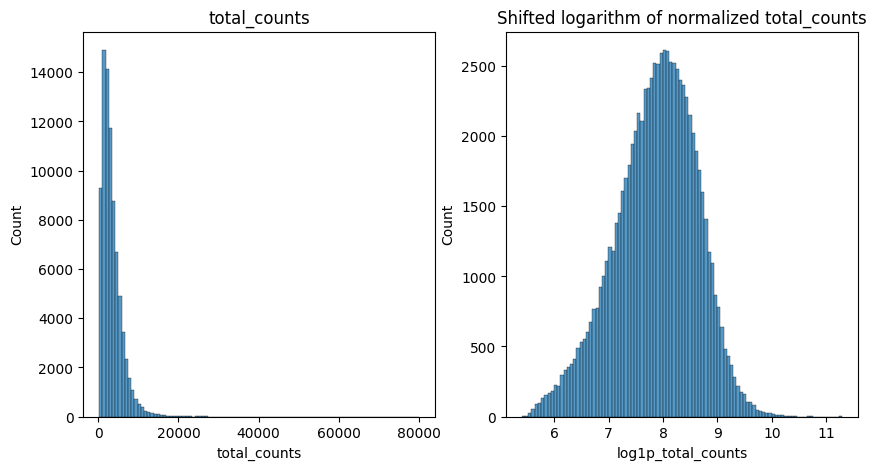

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("total_counts")
sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm of normalized total_counts")
plt.show()

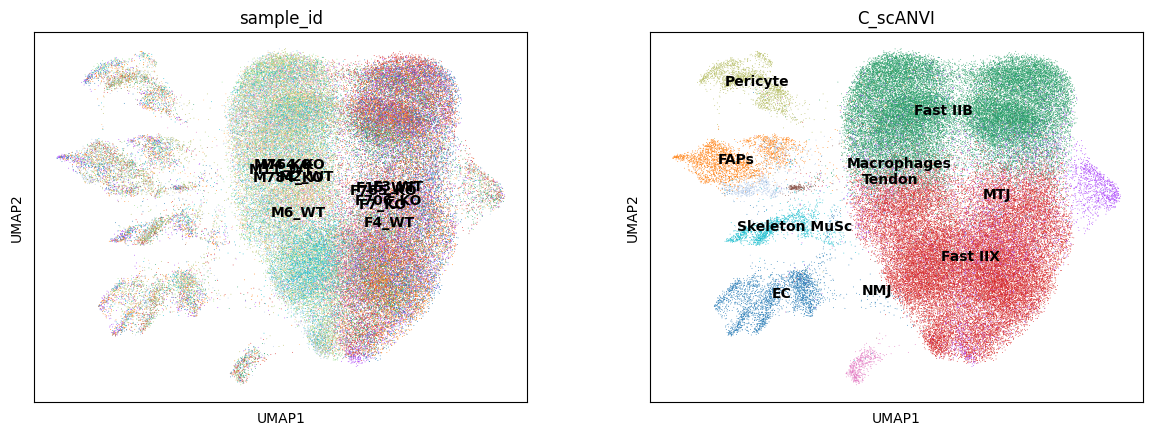

In [8]:
sc.pl.umap(adata, color=["sample_id", "C_scANVI"], legend_loc="on data")

In [9]:
ko_adata_subset = adata[adata.obs['condition'] == 'KO']
wt_adata_subset = adata[adata.obs['condition'] == 'WT']

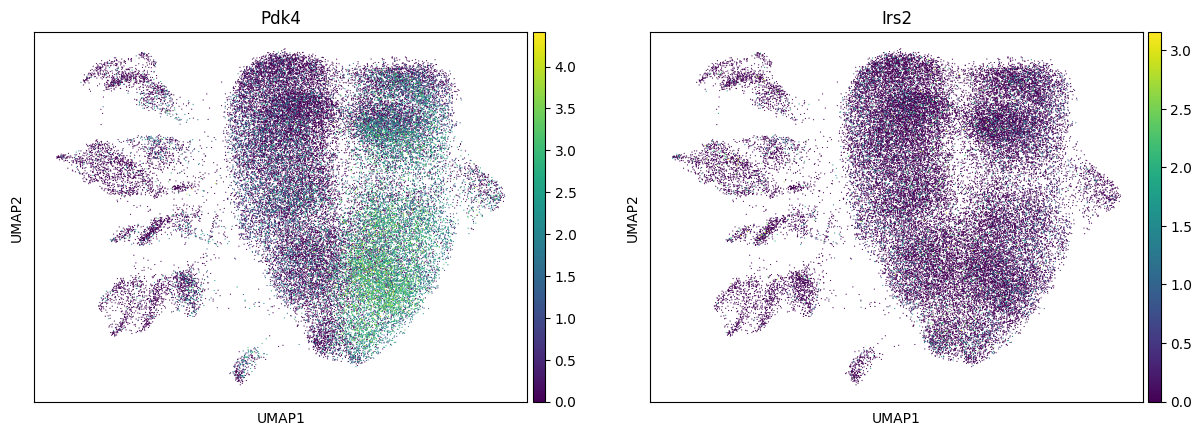

In [10]:
sc.pl.umap(ko_adata_subset, color=['Pdk4', 'Irs2'])